# Spin-orbit coupling: a band gap made of nothing else

With `noncolin = .true.` a wavefunction becomes a two-component spinor, so there
is *one* Hamiltonian on a space twice as large rather than two Hamiltonians on
separate channels. `lspinorb = .true.` then puts the $j$-resolved projectors of a
fully relativistic dataset into it, and the coupling

$$H_{\rm SO} \propto \boldsymbol\sigma \cdot \mathbf L$$

enters through them. A scalar-relativistic dataset keeps one projector per $l$,
the weighted average of the two; a fully relativistic one keeps both
$j = l - \tfrac12$ and $j = l + \tfrac12$, and their difference is the physics.

On QE's three platinum benchmarks, one per kind of dataset:

| | defumat | `pw.x` |
|---|---|---|
| ultrasoft, LDA | **-69.491529507 Ry** | -69.491529520 |
| ultrasoft, PBE | **-90.199533906 Ry** | -90.199533910 |
| PAW, PBE | **-753.342691622 Ry** | -753.342691630 |
| eigenvalues | | agree to **3.6e-4 eV** |

And on bismuthene, a honeycomb layer of bismuth: a direct gap of **0.1361 eV**
without the coupling and **0.6295 eV** with it. The material is a quantum spin
Hall insulator, whose invariant notebook 10 computes, and the gap that makes it
one exists only because bismuth is heavy.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.io import comparison_table, read_qe_output
from defumat.units import RY_TO_EV

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_spinorbit")
PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")

# the input asks for 1e-8; the reference was generated at 1e-10
platinum = Calculator.from_file(QE / "spinorbit.in", pseudo_dir=PSEUDO,
                                conv_thr=1e-10).get_scf(max_iterations=100)
print("fcc platinum, ultrasoft LDA:   E = %.9f Ry" % platinum.total_energy)

fcc platinum, ultrasoft LDA:   E = -69.491529507 Ry


The same run on the other two kinds of fully relativistic dataset, against the
reference `pw.x` output for each:

In [2]:
rows = [("ultrasoft, LDA", platinum.total_energy,
         read_qe_output(CASES / "reference.out.pw_spinorbit-spinorbit").total_energy)]
for name, label in (("spinorbit-pbe", "ultrasoft, PBE"), ("spinorbit-paw", "PAW, PBE")):
    scf = Calculator.from_file(QE / f"{name}.in", pseudo_dir=PSEUDO,
                               conv_thr=1e-10).get_scf(max_iterations=100)
    theirs = read_qe_output(CASES / f"reference.out.pw_spinorbit-{name}")
    rows.append((label, scf.total_energy, theirs.total_energy))

print(comparison_table(rows, fmt="{:.9f}",
                       headers=("dataset", "defumat [Ry]", "pw.x", "difference")))

dataset           defumat [Ry]            pw.x  difference
ultrasoft, LDA   -69.491529507   -69.491529520     1.3e-08
ultrasoft, PBE   -90.199533906   -90.199533910     3.8e-09
PAW, PBE        -753.342691622  -753.342691630     8.5e-09


Three datasets, three ways of carrying $j$, and the agreement is the same in all
three. The k-point weights in these runs sum to **one** rather than two, because
a spinor band holds one electron and not a pair.

Platinum has both an inversion centre and time-reversal symmetry, and those two
together force every level to stay doubly degenerate however strong the coupling
is. That is Kramers' theorem, and it is a statement the calculation has to
satisfy rather than one it is told. The check runs over the levels that hold
electrons: the nearly empty ones at the top carry no charge and are converged
less tightly, so their pairs are only as degenerate as that looser convergence.
Over the filled levels:

In [3]:
levels = np.asarray(platinum.eigenvalues)
weights = np.asarray(platinum.occupations)
filled = weights / weights[:, :1] >= 0.01   # levels holding at least 1% of an electron
split = np.abs(levels[:, 0::2] - levels[:, 1::2]) * RY_TO_EV
print("largest splitting within a Kramers pair, over every filled level:  %.1e eV"
      % split[filled[:, 0::2] & filled[:, 1::2]].max())

largest splitting within a Kramers pair, over every filled level:  2.5e-12 eV


## Bismuthene, where the gap *is* the coupling

Two bismuth atoms in a honeycomb layer. Without spin-orbit coupling the bands
approach each other near K in something close to a Dirac point; with it they do
not, and what opens is a gap of about half an electronvolt. The two runs differ
by two keywords and nothing else.

Run at the test size, 20 Ry and a 6x6x1 grid. The converged pair, 35 Ry and
12x12x1, is committed beside it with its own reference and takes about forty
minutes at a peak of 9.4 GB.

In [4]:
scf, bands = {}, {}
for tag in ("nosoc", "soc"):
    calc = Calculator.from_file(CASES / f"bismuthene-{tag}-small.in",
                                pseudo_dir=PSEUDO)
    scf[tag] = calc.get_scf(max_iterations=100)
    # only the k-path comes from the bands input; the density is already here
    path = Calculator.from_file(CASES / f"bismuthene-{tag}-small-bands.in",
                                pseudo_dir=PSEUDO).system
    bands[tag] = calc.get_bands(kpoints=path.kpoints, nbnd=path.nbnd)

    occupied = round(sum(calc.pseudos[t].z_valence
                         for t in calc.system.structure.types)
                     / (1 if calc.system.nspin == 4 else 2))
    levels = bands[tag].eigenvalues_ev
    gap = (levels[:, occupied] - levels[:, occupied - 1]).min()
    print("%6s   nspin=%d npol=%d   E = %.9f Ry   smallest direct gap %.4f eV"
          % (tag, calc.system.nspin, calc.system.npol,
             scf[tag].total_energy, gap))

 nosoc   nspin=1 npol=1   E = -296.198389843 Ry   smallest direct gap 0.1362 eV


   soc   nspin=4 npol=2   E = -295.610282417 Ry   smallest direct gap 0.6296 eV


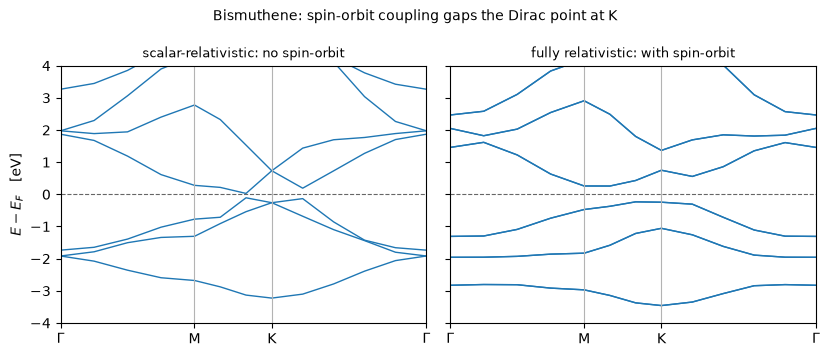

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), sharey=True)
for ax, tag, title in ((axes[0], "nosoc", "scalar-relativistic: no spin-orbit"),
                       (axes[1], "soc", "fully relativistic: with spin-orbit")):
    x = bands[tag].path_length
    ax.plot(x, bands[tag].eigenvalues_ev - scf[tag].fermi_energy * RY_TO_EV,
            color="C0", lw=1.0)
    ax.axhline(0.0, color="0.4", lw=0.8, ls="--")
    corners = [0, 4, 7, 12]
    for corner in corners[1:-1]:
        ax.axvline(x[corner], color="0.7", lw=0.8)
    ax.set_xticks([x[c] for c in corners])
    ax.set_xticklabels([r"$\Gamma$", "M", "K", r"$\Gamma$"])
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-4.0, 4.0)
    ax.set_title(title, fontsize=9)
axes[0].set_ylabel(r"$E - E_F$   [eV]")
fig.suptitle("Bismuthene: spin-orbit coupling gaps the Dirac point at K", fontsize=10)
fig.tight_layout()

The left panel nearly closes at K and the right one does not. Nothing else about
the two calculations differs, so the gap on the right is the coupling and
nothing else, which is what makes bismuthene topological rather than merely
narrow-gapped.

## Forces, the stress and a relaxation

A spinor ground state has a force and a stress like any other, obtained by
differentiating the total energy at frozen wavefunctions. Measured against a
central difference of the *converged* energy along a bond of doubled fcc
platinum, two routes that share nothing and neither of which involves Quantum
ESPRESSO, they agree to **1.5e-5 Ry/bohr** -- a number quoted here from an
offline run, because it costs five self-consistent spinor calculations. The
suite runs the sharper version of the same idea, differencing the *frozen*
energy the gradient is actually taken of, where the agreement is 6.2e-9. The
two differ by how much the density is allowed to relax between the points, and
the looser number is the more honest test of the force a user gets.

Against `pw.x` a four-atom
noncollinear hydrogen chain agrees to 8.9e-7 Ry/bohr, doubled platinum with
spin-orbit coupling to 7.5e-6 (ultrasoft) and 7.3e-7 (PAW), and the stress on
six cases to 1.2e-6 Ry/bohr³.

## What it refuses

The **analytic transcriptions** of QE's force and stress expressions have no
spinor form and are refused by name; the differentiated route is the one that
works. Above the Sternheimer solver, a spinor run has no **elastic constants**
and no **electrostriction**: those reach the energy functional directly and
their first-order wavefunctions would come from a solve with no spinor form.
Spin-orbit coupling with a **spin spiral** is refused permanently, because a
spiral rests on the generalized Bloch theorem and the coupling breaks it, and a
fully relativistic **ultrasoft or PAW** dataset has no site-resolved angular
momenta here, the spinor overlap's off-diagonal spin blocks being missing from
that projection.

---
The tests behind this notebook: `tests/regression/test_spinorbit.py`,
`tests/regression/test_spinor_forces.py`, and
`tests/unit/test_spinorbit_coefficients.py`, which checks that `dvan_so` is
built from the unzeroed `fcoef` and `qq_so` from the zeroed one.